In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))

from spectral_detection.analysis.pipeline import build_training_dataset_eigen_only, build_training_dataset_eigen_attn

import torch
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

## MMLU Training

In [11]:
df_pca_labeled = pd.read_csv(r"../data/spectral/temp_1/mmlu_t1.0_n1_pca.csv")
df_pca_labeled.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC248,PC249,PC250,PC251,PC252,PC253,PC254,PC255,PC256,label
0,28.095276,19.478260,4.851644,-18.490553,-6.517481,-16.811707,-7.449642,-0.066912,10.273495,-7.211306,...,0.406681,3.143919,2.188763,-3.344073,-0.916386,1.875205,1.235977,-0.513229,-2.119722,0
1,17.192364,4.522411,5.463374,9.894541,-8.939284,-14.678637,-7.786315,9.399776,-8.389648,8.575681,...,3.926708,1.084750,-0.531639,0.469483,-0.889730,-1.746062,1.057041,2.490813,-2.010676,0
2,25.700373,-15.575459,7.821295,1.181098,-15.325212,-12.097448,15.802588,6.666360,-6.045384,-3.426746,...,-0.347627,0.105198,-0.002728,1.708326,-0.337343,-1.666915,1.710841,-3.693965,-3.596100,1
3,-32.283253,29.817276,-12.415431,12.504065,-14.984470,5.352422,2.917754,13.761663,-9.107232,-3.770987,...,1.364413,1.076232,0.978949,-1.874394,-2.715371,0.919061,-1.318345,3.488672,-0.407331,1
4,8.332993,-12.712510,-7.955021,3.517987,-0.781271,5.736743,3.065509,-2.108046,7.123956,1.174078,...,-2.663427,0.596237,-1.161288,-0.133689,0.081830,1.010095,0.741410,-0.651265,-0.024162,0


In [12]:
classes = df_pca_labeled["label"].unique()
print("Unique classes in the dataset:", classes)

Unique classes in the dataset: [0 1]


In [ ]:
# data = torch.load("../data/processed/df_pca.pt", map_location="cpu")

# X = data["X"].numpy()
# ids = data["id"]
# datasets = data["dataset"]

# # rebuild dataframe
# pc_cols = [f"PC{i+1}" for i in range(X.shape[1])]

# df_pca = pd.DataFrame(X, columns=pc_cols)
# df_pca.insert(0, "id", ids)
# df_pca.insert(1, "dataset", datasets)

# df_pca.head()

In [ ]:
# df_pca_labeled["label"].unique()

array([0, 1], dtype=int64)

In [14]:
df_pca_labeled.value_counts("label", dropna=False)

label
0    3673
1    1327
Name: count, dtype: int64

In [15]:
# df_pca_labeled should have columns: PC1..PCn and a label column with:

LABEL_COL = "label"  # <-- change if your column name is different


df_train = df_pca_labeled.copy()

# -------------------------
# Build X (PC columns) and y (2-class labels)
# -------------------------
pc_cols = [c for c in df_train.columns if c.startswith("PC")]
X = df_train[pc_cols].to_numpy()
y = df_train[LABEL_COL].to_numpy()

print("X shape:", X.shape)
print("y distribution:\n", pd.Series(y).value_counts())

X shape: (5000, 256)
y distribution:
 0    3673
1    1327
Name: count, dtype: int64


In [ ]:
# -------------------------
# Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=137,
    stratify=y
)

# -------------------------
# Multi-class classifier
#    (Logistic regression supports multinomial)
# -------------------------
log_clf = Pipeline([
    ("scaler", StandardScaler()),  # PCs are already scaled-ish, but this is safe
    ("lr", LogisticRegression(
        penalty="l2",
        max_iter=2000,
        C=0.001,        
        class_weight="balanced",   # helps if classes are imbalanced
        # multi_class="multinomial",
        # solver="lbfgs",
        # l1_ratio=0.2,              # elastic net mixing
    ))
])

log_clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=2000))])

In [ ]:
# -------------------------
# Evaluate
# -------------------------
y_pred = log_clf.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=classes),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))


Classification report:
              precision    recall  f1-score   support

           0      0.847     0.693     0.762       735
           1      0.434     0.653     0.521       265

    accuracy                          0.682      1000
   macro avg      0.640     0.673     0.642      1000
weighted avg      0.737     0.682     0.698      1000


Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1
true_0     509     226
true_1      92     173


AUROC (incorrect as positive): 0.7443357720446669


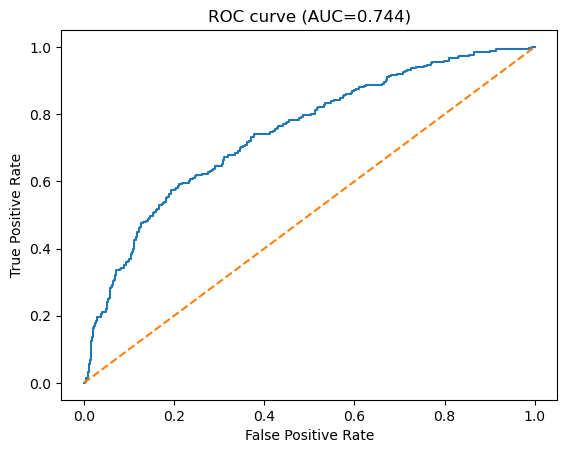

In [27]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# y_true = (np.array(y_test) == "incorrect").astype(int)

# probability score for the positive class ("incorrect")
pos_idx = list(log_clf.classes_).index(1)   # important: don't assume column order
y_score = log_clf.predict_proba(X_test)[:, pos_idx]

# AUROC
auc = roc_auc_score(y_test, y_score)
print("AUROC (incorrect as positive):", auc)

# Optional: plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={auc:.3f})")
plt.show()

## nq_Open Training

In [5]:
df_pca_labeled = pd.read_csv(r"../data/spectral/temp_1/nq_open.csv")
print(df_pca_labeled.head())

classes = df_pca_labeled["label"].unique()
print("Unique classes in the dataset:", classes)

# df_pca_labeled should have columns: PC1..PCn and a label column with:

LABEL_COL = "label"  # <-- change if your column name is different


df_train = df_pca_labeled.copy()

# -------------------------
# Build X (PC columns) and y (2-class labels)
# -------------------------
pc_cols = [c for c in df_train.columns if c.startswith("PC")]
X = df_train[pc_cols].to_numpy()
y = df_train[LABEL_COL].to_numpy()

print("X shape:", X.shape)
print("y distribution:\n", pd.Series(y).value_counts())

         PC1        PC2        PC3        PC4        PC5        PC6  \
0 -28.606780 -10.033399  -0.936449  20.720320 -10.276968  -2.741010   
1   6.530851   8.132322 -22.158134 -16.959623  -7.864002  -6.322720   
2 -13.539382 -12.022514 -11.374075   7.810328   0.082710  -8.850789   
3 -14.507421   1.560368   3.363966  -1.508545  13.914618 -13.189336   
4  -1.169939  11.841800  11.852506  -8.863430  -9.387660 -14.981409   

         PC7       PC8        PC9      PC10  ...     PC120     PC121  \
0   3.564272 -4.955451  -0.203194  6.748618  ... -1.870915 -2.801402   
1 -16.405203 -1.852743   7.896513  4.429062  ... -0.956909 -1.230122   
2   1.351140 -9.890763  13.091425 -9.432151  ...  0.309495 -0.734851   
3  -6.720327 -6.447372  -1.174421 -5.769156  ...  4.535730 -4.748932   
4 -16.684906  2.827239   2.943560  6.609247  ... -0.022526  0.187337   

      PC122     PC123     PC124     PC125     PC126     PC127     PC128  label  
0  4.684344 -2.188635  4.586585 -1.574654 -3.917422  2.4856

In [ ]:
# -------------------------
# Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=137,
    stratify=y
)

# -------------------------
# Multi-class classifier (Logistic regression supports multinomial)
# -------------------------
log_clf = Pipeline([
    ("scaler", StandardScaler()),  # PCs are already scaled-ish, but this is safe
    ("lr", LogisticRegression(
        penalty="l2",
        max_iter=5000,
        C=0.001,        
        class_weight="balanced",   # helps if classes are imbalanced
        # multi_class="multinomial",
        # solver="saga",
        # l1_ratio=0.8,              # elastic net mixing
    ))
])

log_clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=5000))])

In [ ]:
# -------------------------
# Evaluate
# -------------------------
y_pred = log_clf.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=classes),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))


Classification report:
              precision    recall  f1-score   support

           0      0.772     0.595     0.672       519
           1      0.344     0.547     0.422       201

    accuracy                          0.582       720
   macro avg      0.558     0.571     0.547       720
weighted avg      0.653     0.582     0.603       720


Confusion matrix (rows=true, cols=pred):
        pred_1  pred_0
true_1     110      91
true_0     210     309


AUROC (incorrect as positive): 0.599353904849548


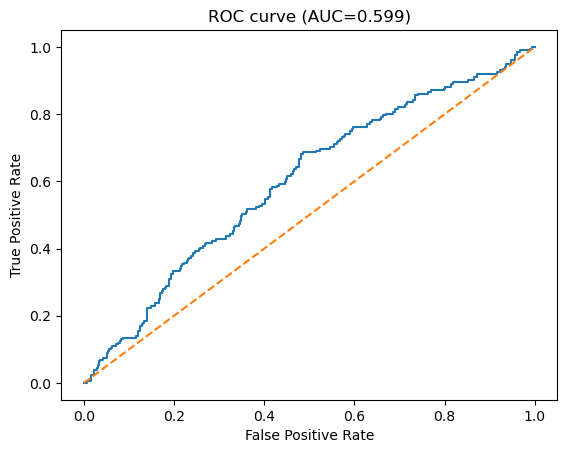

In [27]:
# y_true = (np.array(y_test) == "incorrect").astype(int)

# probability score for the positive class ("incorrect")
pos_idx = list(log_clf.classes_).index(1)   # important: don't assume column order
y_score = log_clf.predict_proba(X_test)[:, pos_idx]

# AUROC
auc = roc_auc_score(y_test, y_score)
print("AUROC (incorrect as positive):", auc)

# Optional: plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={auc:.3f})")
plt.show()

## Triviaqa + MMLU

In [2]:
df_pca_TM = pd.read_csv(r"../data/spectral/temp_1/triviaqa_mmlu_pca.csv")
# df_pca_mmlu = pd.read_csv(r"../data/spectral/temp_1/mmlu_pca.csv")

# df_stacked = pd.concat([df_pca_triviaqa, df_pca_mmlu], axis=0, ignore_index=True)

print(df_pca_TM.head())

classes = df_pca_TM["label"].unique()
print("Unique classes in the dataset:", classes)

# df_pca_labeled should have columns: PC1..PCn and a label column with:

LABEL_COL = "label"  # <-- change if your column name is different


df_train = df_pca_TM.copy()

# -------------------------
# Build X (PC columns) and y (2-class labels)
# -------------------------
pc_cols = [c for c in df_train.columns if c.startswith("PC")]
X = df_train[pc_cols].to_numpy()
y = df_train[LABEL_COL].to_numpy()

print("X shape:", X.shape)
print("y distribution:\n", pd.Series(y).value_counts())

         PC1        PC2        PC3        PC4        PC5       PC6        PC7  \
0  -1.094865  27.862167 -26.793908  12.981636   9.381119  6.708258  -1.340294   
1  -2.032936  14.817370 -23.542576  16.847013  14.676365 -1.994764   6.884055   
2  39.350086  10.462175  47.182297  -3.746812   0.416630  3.043195   2.298111   
3  -5.219615  24.006729 -16.933551   8.035086  -2.114434  8.607027   7.773032   
4  31.986464  16.919031  12.676443  -7.486537  -5.267607 -6.135123 -12.971660   

         PC8        PC9       PC10  ...     PC376     PC377     PC378  \
0  -5.389115  -6.179338  13.179383  ...  1.141642 -1.513671 -0.356864   
1  -6.623255 -10.491322  -4.347425  ...  0.640012  1.805900 -0.805777   
2  13.113747  -4.731201   3.543718  ...  1.910907 -0.814500 -0.884993   
3  -5.978483  -8.853668  -0.382581  ... -0.982953  3.229909  1.547978   
4   1.598459   4.758632  -8.732115  ... -0.810313  0.893578 -3.911738   

      PC379     PC380     PC381     PC382     PC383     PC384  label  
0 -

In [ ]:
# -------------------------
# Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# Binary-class classifier (Logistic regression)
# -------------------------
log_clf = Pipeline([
    ("scaler", StandardScaler()),  # PCs are already scaled-ish, but this is safe
    ("lr", LogisticRegression(
        penalty="l2",
        max_iter=5000,
        C=0.001,        
        class_weight="balanced",   # helps if classes are imbalanced
        # multi_class="multinomial",
        # solver="saga",
        # l1_ratio=0.8,              # elastic net mixing
    ))
])

log_clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=5000))])

In [ ]:
# -------------------------
# Evaluate
# -------------------------
y_pred = log_clf.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=classes),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))


Classification report:
              precision    recall  f1-score   support

           0      0.752     0.684     0.716      1166
           1      0.607     0.685     0.644       834

    accuracy                          0.684      2000
   macro avg      0.680     0.684     0.680      2000
weighted avg      0.692     0.684     0.686      2000


Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1
true_0     797     369
true_1     263     571


AUROC (incorrect as positive): 0.7516206588759867


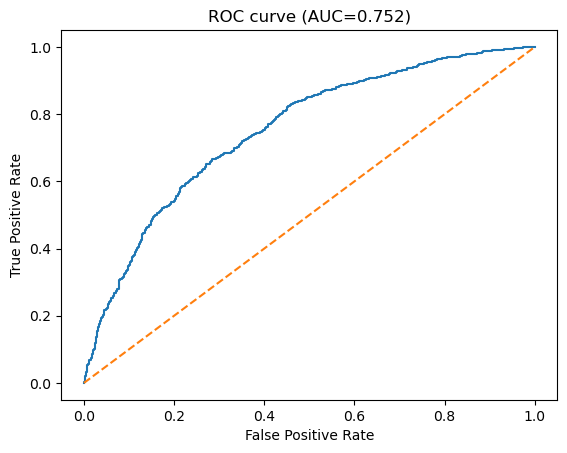

In [5]:
# y_true = (np.array(y_test) == "incorrect").astype(int)

# probability score for the positive class ("incorrect")
pos_idx = list(log_clf.classes_).index(1)   # important: don't assume column order
y_score = log_clf.predict_proba(X_test)[:, pos_idx]

# AUROC
auc = roc_auc_score(y_test, y_score)
print("AUROC (incorrect as positive):", auc)

# Optional: plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={auc:.3f})")
plt.show()

## Halueval Training

In [6]:
df_pca_labeled = pd.read_csv(r"../data/spectral/temp_1/halueval_t1.0_n1_pca.csv")
print(df_pca_labeled.head())

classes = df_pca_labeled["label"].unique()
print("Unique classes in the dataset:", classes)

# df_pca_labeled should have columns: PC1..PCn and a label column with:

LABEL_COL = "label"  # <-- change if your column name is different


df_train = df_pca_labeled.copy()

# -------------------------
# Build X (PC columns) and y (2-class labels)
# -------------------------
pc_cols = [c for c in df_train.columns if c.startswith("PC")]
X = df_train[pc_cols].to_numpy()
y = df_train[LABEL_COL].to_numpy()

print("X shape:", X.shape)
print("y distribution:\n", pd.Series(y).value_counts())

         PC1       PC2        PC3        PC4       PC5        PC6       PC7  \
0  23.745983 -4.078446  -5.536303  -9.591764  3.527650  -5.588723  9.179587   
1  -8.324484 -3.371192  16.541830   2.547776 -7.275225  24.000263  5.934997   
2 -35.974052 -7.751545 -39.317482  19.957874  1.220803 -24.410510 -0.044090   
3  15.101802 -7.308723   4.300932  -6.253857  1.836299   4.708517 -3.641397   
4 -11.150685  0.132028  16.755690 -13.999758 -8.046125  10.271860 -7.938184   

        PC8        PC9      PC10  ...     PC248     PC249     PC250     PC251  \
0  4.338895  -7.959638 -4.226568  ...  0.837641 -1.462271  1.216665  3.700047   
1  6.335870 -16.427061  1.983333  ... -1.390460 -0.247518  1.140044 -3.327961   
2  9.653060  -9.045791  4.235573  ... -1.851807 -0.317285 -2.679782  2.727677   
3  9.053051   0.477310 -7.454600  ...  3.402055  1.062985 -1.837196 -2.997785   
4  6.917554   3.589669  5.085630  ... -3.978410  1.816745 -0.400447  0.926974   

      PC252     PC253     PC254     PC

In [ ]:
# -------------------------
# Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=137,
    stratify=y
)

# -------------------------
# Binary-class classifier (Logistic regression)
# -------------------------
log_clf = Pipeline([
    ("scaler", StandardScaler()),  # PCs are already scaled-ish, but this is safe
    ("lr", LogisticRegression(
        # penalty="l2",
        max_iter=2000,
        # C=0.001,        
        class_weight="balanced",   # helps if classes are imbalanced
        # multi_class="multinomial",
        # solver="saga",
        # l1_ratio=0.8,              # elastic net mixing
    ))
])

log_clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [ ]:
# -------------------------
# Evaluate
# -------------------------
y_pred = log_clf.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=classes),
                   index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]))


Classification report:
              precision    recall  f1-score   support

           0      0.776     0.645     0.705      1364
           1      0.441     0.601     0.509       636

    accuracy                          0.631      2000
   macro avg      0.609     0.623     0.607      2000
weighted avg      0.670     0.631     0.642      2000


Confusion matrix (rows=true, cols=pred):
        pred_1  pred_0
true_1     382     254
true_0     484     880


AUROC (incorrect as positive): 0.6478137276600453


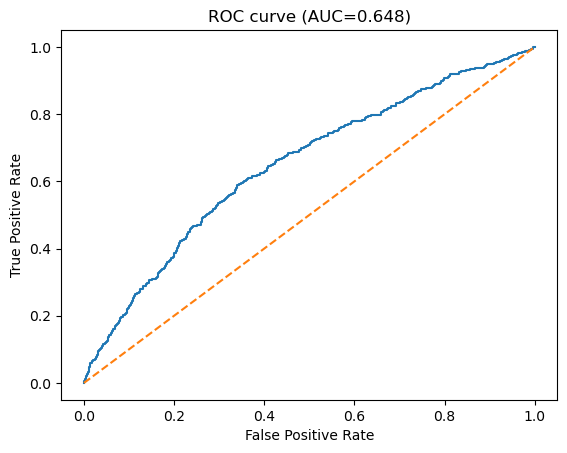

In [9]:
# y_true = (np.array(y_test) == "incorrect").astype(int)

# probability score for the positive class ("incorrect")
pos_idx = list(log_clf.classes_).index(1)   # important: don't assume column order
y_score = log_clf.predict_proba(X_test)[:, pos_idx]

# AUROC
auc = roc_auc_score(y_test, y_score)
print("AUROC (incorrect as positive):", auc)

# Optional: plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={auc:.3f})")
plt.show()

## Make a Combined Dataset 

We make a combined dataset for further analysis with different classifiers, Hyperparameter tuning, anb visualizations.

In [26]:
import os
import torch
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import json

In [27]:
eigen_pt = r"../data/spectral/temp_1/triviaqa_Judgelabels_and_eigs_top10.pt"

payload = torch.load(eigen_pt, map_location="cpu")

# print(type(payload))
# print(payload.keys())

rows = []

for sample_id, item in payload["data"].items():

    eigvals = item["eig_top10"].numpy()

    row = {
        "id": sample_id,
        "label": item["label"],
        # "domain": item.get("domain", None),
    }

    # expand eigenvalues into columns
    for i, v in enumerate(eigvals):
        row[f"eig_{i}"] = float(v)

    rows.append(row)

df1 = pd.DataFrame(rows)
   

In [28]:
df1["label"] = df1["label"].apply(lambda x: 1 if x.lower() == "incorrect" else 0)
df1.head()

,id,label,eig_0,eig_1,eig_2,eig_3,eig_4,eig_5,eig_6,eig_7,...,eig_6710,eig_6711,eig_6712,eig_6713,eig_6714,eig_6715,eig_6716,eig_6717,eig_6718,eig_6719
0,triviaqa_00000_t1.0_ans00,1,0.353516,0.104980,0.081055,0.072754,0.053711,0.046875,0.038818,0.032227,...,0.005249,0.001221,0.000977,0.000000,-0.000557,-0.002380,-0.002502,-0.003708,-0.004761,-0.005432
1,triviaqa_00001_t1.0_ans00,1,0.261719,0.112793,0.056641,0.050781,0.027832,0.025879,0.024536,0.020752,...,0.042969,0.011902,0.001709,0.001404,0.000000,-0.000305,-0.001587,-0.002716,-0.002945,-0.003052
2,triviaqa_00002_t1.0_ans00,0,0.283203,0.201172,0.089844,0.088867,0.067871,0.065430,0.054199,0.042725,...,0.030273,0.005493,0.004761,0.000366,0.000000,-0.000664,-0.000671,-0.001297,-0.003204,-0.003265
3,triviaqa_00003_t1.0_ans00,1,0.178711,0.142578,0.044434,0.039307,0.033203,0.030518,0.029175,0.025757,...,0.012085,0.002869,0.002808,0.001495,0.000916,0.000000,-0.000366,-0.001984,-0.002289,-0.003143
4,triviaqa_00004_t1.0_ans00,1,0.127930,0.073730,0.064941,0.052002,0.038330,0.037598,0.026855,0.023438,...,0.007385,0.006104,0.005157,0.003326,0.002197,0.000000,-0.000519,-0.001190,-0.002518,-0.003113


In [29]:
df1["dataset"] = "triviaqa"
df1.head()

,id,label,eig_0,eig_1,eig_2,eig_3,eig_4,eig_5,eig_6,eig_7,...,eig_6711,eig_6712,eig_6713,eig_6714,eig_6715,eig_6716,eig_6717,eig_6718,eig_6719,dataset
0,triviaqa_00000_t1.0_ans00,1,0.353516,0.104980,0.081055,0.072754,0.053711,0.046875,0.038818,0.032227,...,0.001221,0.000977,0.000000,-0.000557,-0.002380,-0.002502,-0.003708,-0.004761,-0.005432,triviaqa
1,triviaqa_00001_t1.0_ans00,1,0.261719,0.112793,0.056641,0.050781,0.027832,0.025879,0.024536,0.020752,...,0.011902,0.001709,0.001404,0.000000,-0.000305,-0.001587,-0.002716,-0.002945,-0.003052,triviaqa
2,triviaqa_00002_t1.0_ans00,0,0.283203,0.201172,0.089844,0.088867,0.067871,0.065430,0.054199,0.042725,...,0.005493,0.004761,0.000366,0.000000,-0.000664,-0.000671,-0.001297,-0.003204,-0.003265,triviaqa
3,triviaqa_00003_t1.0_ans00,1,0.178711,0.142578,0.044434,0.039307,0.033203,0.030518,0.029175,0.025757,...,0.002869,0.002808,0.001495,0.000916,0.000000,-0.000366,-0.001984,-0.002289,-0.003143,triviaqa
4,triviaqa_00004_t1.0_ans00,1,0.127930,0.073730,0.064941,0.052002,0.038330,0.037598,0.026855,0.023438,...,0.006104,0.005157,0.003326,0.002197,0.000000,-0.000519,-0.001190,-0.002518,-0.003113,triviaqa


In [13]:
eig_cols = [col for col in df1.columns if col.startswith("eig_")]
X1 = df1[eig_cols].values
y1 = df1["label"].values

In [65]:
jsonl_pt_mmlu = r"../data/spectral/temp_1/mmlu_t1.0_n1.jsonl"
eigen_pt_mmlu = r"../data/spectral/temp_1/mmlu_t1.0_n1_eigen.pt"

df2, X2, y2 = build_training_dataset_eigen_attn(jsonl_pt_mmlu, eigen_pt_mmlu)

Feature Matrix (X) shape: (5000, 6720)
Label Vector (y) shape: (5000,)


In [68]:
df2['attention_score'][0].shape

(672,)

In [71]:
df2_vec = pd.DataFrame(df2["features"].tolist(), index=df2.index)
df2_vec.columns = [f"eig_{i}" for i in range(df2_vec.shape[1])]  # eig000..eig199

df2_attn = pd.DataFrame(df2["attention_score"].tolist(), index=df2.index)
df2_attn.columns = [f"attn_{i}" for i in range(df2_attn.shape[1])]

cols = ["features", "question", "topic_label", "model_answer", "temperature", "prompt_tokens", "generated_tokens", "timestamp", "type", 
        "domain", "correctness", "adversarial", "correctness_score", "reference_answer", "sample_num", "prompt_id", "attention_score"]

df2_1 = pd.concat([df2.drop(columns=cols), df2_vec, df2_attn], axis=1)
df2_1.head()

,id,dataset,label,eig_0,eig_1,eig_2,eig_3,eig_4,eig_5,eig_6,...,attn_662,attn_663,attn_664,attn_665,attn_666,attn_667,attn_668,attn_669,attn_670,attn_671
0,mmlu_00000_t1.0_ans00,mmlu,1,0.406250,0.179688,0.083984,0.047852,0.044678,0.037598,0.024536,...,-4.96875,-5.06250,-4.96875,-3.87500,-1.781250,-1.945312,-1.515625,-2.968750,-3.906250,-3.796875
1,mmlu_00001_t1.0_ans00,mmlu,1,0.146484,0.135742,0.048828,0.014343,0.013916,0.013306,0.012756,...,-5.03125,-5.03125,-5.15625,-3.78125,-1.906250,-2.078125,-1.578125,-3.296875,-3.734375,-3.781250
2,mmlu_00002_t1.0_ans00,mmlu,0,0.160156,0.079590,0.067383,0.063965,0.023682,0.018188,0.017334,...,-4.93750,-5.12500,-4.75000,-3.62500,-2.015625,-2.140625,-1.523438,-3.015625,-3.671875,-3.578125
3,mmlu_00003_t1.0_ans00,mmlu,0,0.145508,0.080078,0.040039,0.023438,0.022583,0.019287,0.017212,...,-4.81250,-4.96875,-4.87500,-3.68750,-1.843750,-1.921875,-1.437500,-2.812500,-3.906250,-3.734375
4,mmlu_00004_t1.0_ans00,mmlu,1,0.388672,0.076660,0.050781,0.032715,0.021729,0.011230,0.011108,...,-5.12500,-5.53125,-5.18750,-4.09375,-1.929688,-1.945312,-1.578125,-2.921875,-3.953125,-3.828125


In [37]:
jsonl_pt_halueval = r"../data/spectral/temp_1/halueval_t1.5_n1_1000s_prompt2.jsonl"
eigen_pt_halueval = r"../data/spectral/temp_1/halueval_t1.5_n1_eigen_1000s_prompt2.pt"

df3, X3, y3 = build_training_dataset_eigen_only(jsonl_pt_halueval, eigen_pt_halueval)

Feature Matrix (X) shape: (10000, 6720)
Label Vector (y) shape: (10000,)


In [41]:
df3_vec = pd.DataFrame(df3["features"].tolist(), index=df3.index)
df3_vec.columns = [f"eig_{i}" for i in range(df3_vec.shape[1])]  # eig000..eig199

cols = ["features", "question", "topic_label", "model_answer", "temperature", "prompt_tokens", "generated_tokens", "timestamp", "type", 
        "domain", "correctness", "adversarial", "correctness_score", "reference_answer", "sample_num", "prompt_id"]

df3_1 = pd.concat([df3.drop(columns=cols), df3_vec], axis=1)
df3_1.head()

,id,dataset,label,eig_0,eig_1,eig_2,eig_3,eig_4,eig_5,eig_6,...,eig_6710,eig_6711,eig_6712,eig_6713,eig_6714,eig_6715,eig_6716,eig_6717,eig_6718,eig_6719
0,halueval_00000_t1.5_ans00,halueval,1,0.281250,0.087402,0.034668,0.030640,0.030518,0.024414,0.017944,...,0.015137,0.002869,0.001816,0.000977,0.000000,-0.000221,-0.000549,-0.000671,-0.001488,-0.002350
1,halueval_00001_t1.5_ans00,halueval,0,0.333984,0.186523,0.105469,0.077148,0.065430,0.055908,0.054199,...,0.009033,0.008118,0.007263,0.001724,0.000000,-0.000534,-0.001732,-0.001831,-0.002609,-0.002777
2,halueval_00002_t1.5_ans00,halueval,0,0.091797,0.069336,0.060547,0.050781,0.036133,0.035645,0.034912,...,0.013672,0.011353,0.009399,0.001495,0.000854,0.000015,0.000000,-0.001297,-0.001465,-0.001648
3,halueval_00003_t1.5_ans00,halueval,0,0.289062,0.162109,0.122070,0.049072,0.032715,0.024414,0.022949,...,0.002411,0.000000,-0.000122,-0.000618,-0.001160,-0.001694,-0.001839,-0.001877,-0.002029,-0.002289
4,halueval_00004_t1.5_ans00,halueval,1,0.118164,0.086914,0.082520,0.043945,0.031982,0.022217,0.015991,...,0.000824,0.000526,0.000000,-0.000191,-0.000549,-0.000610,-0.000992,-0.001350,-0.002197,-0.002411


In [51]:
df_all = pd.concat([df1, df2_1, df3_1], axis=0, ignore_index=True, sort=False)
df_all.dataset.value_counts()

dataset
halueval    10000
triviaqa     5000
mmlu         5000
Name: count, dtype: int64

In [52]:
# params
L, H, K = 21, 32, 10
D = L * H * K  # 6720

# make sure the expected columns exist
old_cols = [f"eig_{i}" for i in range(D)]
# missing = [c for c in old_cols if c not in df.columns]
# if missing:
#     raise ValueError(f"Missing expected columns like {missing[:5]} ... (total missing {len(missing)})")

# build new names
new_cols = []
for i in range(D):
    l = i // (H * K)
    r = i % (H * K)
    h = r // K
    k = r % K
    new_cols.append(f"eig_l{l}_h{h}_k{k+1}")  # 0-indexed l,h,k

# apply rename
df_all = df_all.rename(columns=dict(zip(old_cols, new_cols)))

In [53]:
df_all.head()

,id,label,eig_l0_h0_k1,eig_l0_h0_k2,eig_l0_h0_k3,eig_l0_h0_k4,eig_l0_h0_k5,eig_l0_h0_k6,eig_l0_h0_k7,eig_l0_h0_k8,...,eig_l20_h31_k2,eig_l20_h31_k3,eig_l20_h31_k4,eig_l20_h31_k5,eig_l20_h31_k6,eig_l20_h31_k7,eig_l20_h31_k8,eig_l20_h31_k9,eig_l20_h31_k10,dataset
0,triviaqa_00000_t1.0_ans00,1,0.353516,0.104980,0.081055,0.072754,0.053711,0.046875,0.038818,0.032227,...,0.001221,0.000977,0.000000,-0.000557,-0.002380,-0.002502,-0.003708,-0.004761,-0.005432,triviaqa
1,triviaqa_00001_t1.0_ans00,1,0.261719,0.112793,0.056641,0.050781,0.027832,0.025879,0.024536,0.020752,...,0.011902,0.001709,0.001404,0.000000,-0.000305,-0.001587,-0.002716,-0.002945,-0.003052,triviaqa
2,triviaqa_00002_t1.0_ans00,0,0.283203,0.201172,0.089844,0.088867,0.067871,0.065430,0.054199,0.042725,...,0.005493,0.004761,0.000366,0.000000,-0.000664,-0.000671,-0.001297,-0.003204,-0.003265,triviaqa
3,triviaqa_00003_t1.0_ans00,1,0.178711,0.142578,0.044434,0.039307,0.033203,0.030518,0.029175,0.025757,...,0.002869,0.002808,0.001495,0.000916,0.000000,-0.000366,-0.001984,-0.002289,-0.003143,triviaqa
4,triviaqa_00004_t1.0_ans00,1,0.127930,0.073730,0.064941,0.052002,0.038330,0.037598,0.026855,0.023438,...,0.006104,0.005157,0.003326,0.002197,0.000000,-0.000519,-0.001190,-0.002518,-0.003113,triviaqa


In [54]:
pd.DataFrame.to_csv(df_all, r"../data/spectral/temp_1/combined_datasets.csv", index=False)

In [17]:
X = np.vstack([X1, X2])
y = np.hstack([y1, y2])

X.shape, y.shape

((10000, 6720), (10000,))

## Try Different Classifiers to Compare

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
## Logistic regression with PCA

pipe1 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=384, random_state=42)),
    ("lr", LogisticRegression(penalty="l2", max_iter=5000, class_weight="balanced"))
])

pipe1.fit(X_train, y_train)

y_pred = pipe1.predict(X_test)
y_score = pipe1.predict_proba(X_test)[:, 1]   # prob of class 1

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test AUROC:", roc_auc_score(y_test, y_score))

Test accuracy: 0.6745
Test AUROC: 0.7417990136192933


In [20]:
import warnings
warnings.filterwarnings("ignore")

In [21]:
## Linear SVM + calibration

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=768, random_state=42)),
    ("svc", LinearSVC(C=1.0, max_iter=20000))   # increase iterations for SVC too
])

cal = CalibratedClassifierCV(
    estimator=base,
    method="sigmoid",   # simpler than isotonic, often enough
    cv=3                # lower cv reduces calibration fits
)

cal.fit(X_train, y_train)

y_pred = cal.predict(X_test)
y_score = cal.predict_proba(X_test)[:, 1]   # prob of class 1

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test AUROC:", roc_auc_score(y_test, y_score))

Test accuracy: 0.6825
Test AUROC: 0.7314642282743273


In [22]:
## SGDClassifier (hinge or log loss) with elastic net

from sklearn.linear_model import SGDClassifier

pipe3 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=256, random_state=42)),
    ("clf", SGDClassifier(
        loss= "log_loss",   # or "log_loss" 
        penalty="elasticnet",
        alpha=1e-3,
        l1_ratio=0.25,
        max_iter=5000,
        random_state=42
    ))
])

pipe3.fit(X_train, y_train)

y_pred = pipe3.predict(X_test)
y_score = pipe3.predict_proba(X_test)[:, 1]   # prob of class 1

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test AUROC:", roc_auc_score(y_test, y_score))

Test accuracy: 0.634
Test AUROC: 0.6751689557444953


In [23]:
## RandomForest / ExtraTrees with PCA

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

pipe4 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=384, random_state=0)),
    ("clf", RandomForestClassifier(
    n_estimators=600, max_features="sqrt",
    min_samples_leaf=2, n_jobs=-1, random_state=137
))
])

pipe4.fit(X_train, y_train)

y_pred = pipe4.predict(X_test)
y_score = pipe4.predict_proba(X_test)[:, 1]   # prob of class 1

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test AUROC:", roc_auc_score(y_test, y_score))

Test accuracy: 0.6395
Test AUROC: 0.7102768899802971


In [24]:
## Classic AdaBoost (stumps) 

from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier


# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=137)

ada_stump = Pipeline([
    ("pca", PCA(n_components=512, random_state=0)),   # remove this line to test without PCA
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=137),
        n_estimators=300,
        learning_rate=0.05,
        random_state=137
    ))
])


ada_stump.fit(X_train, y_train)


y_pred = ada_stump.predict(X_test)
y_score = ada_stump.predict_proba(X_test)[:, 1]   # prob of class 1

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test AUROC:", roc_auc_score(y_test, y_score))

Test accuracy: 0.637
Test AUROC: 0.6900201965357388


In [25]:
## AdaBoost with small trees

ada_tree = Pipeline([
    ("pca", PCA(n_components=512, random_state=0)),  # try removing PCA too
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=2, random_state=137),
        n_estimators=400,
        learning_rate=0.05,
        random_state=137
    ))
])

ada_tree.fit(X_train, y_train)

y_pred = ada_stump.predict(X_test)
y_score = ada_stump.predict_proba(X_test)[:, 1]   # prob of class 1

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test AUROC:", roc_auc_score(y_test, y_score))

# auc_scores = cross_val_score(ada_tree, X, y, scoring="roc_auc", cv=cv, n_jobs=-1)
# print("AdaBoost(tree) AUROC mean±std:", auc_scores.mean(), auc_scores.std())

Test accuracy: 0.637
Test AUROC: 0.6900201965357388


## Hyperparameter Tuning

In [60]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=384, random_state=42)),
    ("lr", LogisticRegression(
        solver="saga",
        max_iter=5000,
        class_weight=None,   # we'll tune this
        n_jobs=-1
    ))
])

param_grid = {
    "pca__n_components": [256, 384, 512],
    "pca__whiten": [False, True],
    "lr__penalty": ["l2", "elasticnet"],
    "lr__C": [1e-2, 3e-2, 1e-1],
    "lr__l1_ratio": [0.1, 0.3, 0.5],   # only used for elasticnet; ignored for l2 by GridSearchCV? (sklearn will error)
    "lr__class_weight": [None, "balanced"],
}

# Fix: split the grid so l1_ratio only applies to elasticnet
# param_grid = [
#     {
#         "pca__n_components": [256, 384, 512, 768],
#         "pca__whiten": [False, True],
#         "lr__penalty": ["l2"],
#         "lr__C": [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1],
#         "lr__class_weight": [None, "balanced"],
#     },
#     {
#         "pca__n_components": [256, 384, 512, 768],
#         "pca__whiten": [False, True],
#         "lr__penalty": ["elasticnet"],
#         "lr__C": [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1],
#         "lr__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
#         "lr__class_weight": [None, "balanced"],
#     }
# ]

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

gs = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gs.fit(X, y)  # y can be strings: 'correct'/'incorrect'
print("Best CV AUROC:", gs.best_score_)
print("Best params:", gs.best_params_)
best_model = gs.best_estimator_

Fitting 2 folds for each of 216 candidates, totalling 432 fits
Best CV AUROC: 0.7287355922607069
Best params: {'lr__C': 0.01, 'lr__class_weight': None, 'lr__l1_ratio': 0.5, 'lr__penalty': 'elasticnet', 'pca__n_components': 256, 'pca__whiten': False}
